# Core Task -- DQN on Highway-v0

**Reinforcement Learning Project - CentraleSupelec 2026**

This notebook implements the shared core task:
1. A DQN agent implemented from scratch (based on TP4, adapted for `highway-v0`)
2. A Stable-Baselines3 DQN baseline for comparison
3. Systematic evaluation across 3 seeds x 50 runs each
4. Qualitative behavior and failure mode analysis

**Environment:** `highway-v0` | **Observations:** `Kinematics` | **Actions:** `DiscreteMetaAction`

In [1]:
# Uncomment to install if needed:
# !pip install highway-env stable-baselines3

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import highway_env  # noqa: F401 -- registers highway-v0 environments
import matplotlib.pyplot as plt
import pandas as pd

from shared_core_config import HIGHWAY_CONFIG, DQN_HYPERPARAMS, SB3_HYPERPARAMS

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

os.makedirs('results/dqn', exist_ok=True)
os.makedirs('results/sb3', exist_ok=True)

c:\Users\marie\OneDrive - edu.escpeurope.eu\CS\RL\RL-project\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## 1. Environment

We use `highway-v0` with:
- **Kinematics** observations: 5 nearby vehicles x 5 features `[presence, x, y, vx, vy]` = **25-dim** flat input
- **DiscreteMetaAction**: 5 actions (LANE_LEFT, IDLE, LANE_RIGHT, FASTER, SLOWER)
- Config from `shared_core_config.py` (shared benchmark across all groups)

In [2]:
env = gym.make('highway-v0', render_mode=None)
env.unwrapped.configure(HIGHWAY_CONFIG)
obs, _ = env.reset(seed=GLOBAL_SEED)

print('Observation space :', env.observation_space)
print('Observation shape :', obs.shape)
print('Sample observation :')
print(obs)
print()
print('Action space      :', env.action_space)

N_OBS = obs.size           # 25 = 5 vehicles x 5 features (flattened)
N_ACTIONS = env.action_space.n  # 5

ACTION_NAMES = {0: 'LANE_LEFT', 1: 'IDLE', 2: 'LANE_RIGHT', 3: 'FASTER', 4: 'SLOWER'}
print(f'Flat obs size : {N_OBS}')
print(f'n_actions     : {N_ACTIONS}')
print(f'Actions       : {ACTION_NAMES}')

Observation space : Box(-inf, inf, (5, 5), float32)
Observation shape : (5, 5)
Sample observation :
[[ 1.          0.894922    0.          0.3125      0.        ]
 [ 1.          0.11214782  0.75       -0.01780258  0.        ]
 [ 1.          0.2252721   0.5        -0.02145726  0.        ]
 [ 1.          0.32675534  0.75       -0.03311053  0.        ]
 [ 1.          0.43310103  0.75       -0.01914644  0.        ]]

Action space      : Discrete(5)
Flat obs size : 25
n_actions     : 5
Actions       : {0: 'LANE_LEFT', 1: 'IDLE', 2: 'LANE_RIGHT', 3: 'FASTER', 4: 'SLOWER'}


## 2. DQN Implementation

We implement DQN following the TP4 architecture, with two adaptations for `highway-v0`:

- **Observation flattening**: the (5, 5) Kinematics matrix is flattened to a 25-dim vector before entering the network
- **Deeper network**: two hidden layers of 256 units (vs. one layer of 128 in TP4) to capture interactions between vehicles

The three core components are:
- `ReplayBuffer`: circular buffer storing past transitions (decorrelates training samples)
- `Net`: 2-layer MLP mapping states to Q-values
- `DQN`: agent with epsilon-greedy exploration, TD updates, and periodic target network sync

These directly address the **deadly triad** instability (Lecture IV): function approximation + bootstrapping + off-policy.

In [6]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, *args):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = args
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.choices(self.memory, k=batch_size)

    def __len__(self):
        return len(self.memory)


class Net(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [7]:
class DQN:
    def __init__(self, n_obs, n_actions, gamma, batch_size, buffer_capacity,
                 update_target_every, epsilon_start, decrease_epsilon_factor,
                 epsilon_min, learning_rate, hidden_size=256, **kwargs):
        self.n_obs = n_obs
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.update_target_every = update_target_every
        self.epsilon_start = epsilon_start
        self.decrease_epsilon_factor = decrease_epsilon_factor
        self.epsilon_min = epsilon_min

        self.buffer = ReplayBuffer(buffer_capacity)
        self.q_net = Net(n_obs, hidden_size, n_actions)
        self.target_net = Net(n_obs, hidden_size, n_actions)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.loss_fn = nn.MSELoss()
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=learning_rate)

        self.epsilon = epsilon_start
        self.n_steps = 0
        self.n_eps = 0

    def get_action(self, state, epsilon=None):
        """Epsilon-greedy action selection."""
        if epsilon is None:
            epsilon = self.epsilon
        if np.random.rand() < epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            s = torch.tensor(state.flatten(), dtype=torch.float32).unsqueeze(0)
            return self.q_net(s).argmax().item()

    def update(self, state, action, reward, done, next_state):
        """Store transition and perform one gradient step."""
        self.buffer.push(
            torch.tensor(state.flatten(), dtype=torch.float32).unsqueeze(0),
            torch.tensor([[action]], dtype=torch.int64),
            torch.tensor([reward], dtype=torch.float32),
            torch.tensor([int(done)], dtype=torch.int64),
            torch.tensor(next_state.flatten(), dtype=torch.float32).unsqueeze(0),
        )
        if len(self.buffer) < self.batch_size:
            return None

        transitions = self.buffer.sample(self.batch_size)
        s_b, a_b, r_b, d_b, ns_b = (torch.cat(x) for x in zip(*transitions))

        q_vals = self.q_net(s_b).gather(1, a_b)
        with torch.no_grad():
            next_q = (1 - d_b) * self.target_net(ns_b).max(1)[0]
            targets = r_b + self.gamma * next_q

        loss = self.loss_fn(q_vals, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.n_steps += 1
        if self.n_steps % self.update_target_every == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

    def decrease_epsilon(self):
        self.epsilon = self.epsilon_min + (
            (self.epsilon_start - self.epsilon_min)
            * np.exp(-self.n_eps / self.decrease_epsilon_factor)
        )

    def save(self, path):
        torch.save({
            'q_net': self.q_net.state_dict(),
            'target_net': self.target_net.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'n_steps': self.n_steps,
            'n_eps': self.n_eps,
            'epsilon': self.epsilon,
        }, path)

    def load(self, path):
        ck = torch.load(path, map_location='cpu', weights_only=False)
        self.q_net.load_state_dict(ck['q_net'])
        self.target_net.load_state_dict(ck['target_net'])
        self.optimizer.load_state_dict(ck['optimizer'])
        self.n_steps = ck['n_steps']
        self.n_eps   = ck['n_eps']
        self.epsilon = ck['epsilon']

## 3. Training Our DQN

We train for **2 000 episodes** (~80 000 total steps at 40 steps/episode).
A greedy evaluation (10 episodes) runs every 200 training episodes to track progress.
Checkpoints are saved so training can be resumed without restarting.

In [8]:
def eval_agent(get_action_fn, env, n_episodes=10, seed=100):
    """Greedy evaluation. Returns array of per-episode rewards."""
    rewards = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        total, done = 0.0, False
        while not done:
            action = get_action_fn(obs)
            obs, r, term, trunc, _ = env.step(action)
            total += r
            done = term or trunc
        rewards.append(total)
    return np.array(rewards)


def smooth(x, w=50):
    if len(x) < w:
        return np.array(x)
    return np.convolve(x, np.ones(w) / w, mode='valid')


def train_dqn(agent, env, n_episodes, eval_freq=200, train_seed=0):
    ep_rewards, ep_losses, eval_log = [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=train_seed + ep)
        ep_reward, step_losses, done = 0.0, [], False

        while not done:
            action = agent.get_action(obs)
            next_obs, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            loss = agent.update(obs, action, reward, done, next_obs)
            if loss is not None:
                step_losses.append(loss)
            obs = next_obs
            ep_reward += reward

        agent.n_eps += 1
        agent.decrease_epsilon()
        ep_rewards.append(ep_reward)
        ep_losses.append(np.mean(step_losses) if step_losses else 0.0)

        if (ep + 1) % eval_freq == 0:
            greedy_fn = lambda o: agent.get_action(o, epsilon=0.0)
            mean_r = eval_agent(greedy_fn, env, n_episodes=10).mean()
            eval_log.append((ep + 1, mean_r))
            print(
                f'[{ep+1:4d}/{n_episodes}]'
                f'  train={np.mean(ep_rewards[-100:]):.3f}'
                f'  eval={mean_r:.3f}'
                f'  eps={agent.epsilon:.3f}'
            )

    return ep_rewards, ep_losses, eval_log

In [9]:
CKPT_DQN = 'results/dqn/dqn_final.pt'
CKPT_DQN_R = 'results/dqn/train_rewards.npy'

# agent = DQN(n_obs=N_OBS, n_actions=N_ACTIONS, **DQN_HYPERPARAMS)

# if os.path.exists(CKPT_DQN):
#     agent.load(CKPT_DQN)
#     dqn_rewards = np.load(CKPT_DQN_R).tolist()
#     print(f'Checkpoint loaded -- {len(dqn_rewards)} episodes already trained.')
# else:
#     dqn_rewards, dqn_losses, dqn_eval = train_dqn(
#         agent, env,
#         n_episodes=DQN_HYPERPARAMS['n_episodes'],
#         train_seed=GLOBAL_SEED,
#     )
#     agent.save(CKPT_DQN)
#     np.save(CKPT_DQN_R, np.array(dqn_rewards))
#     print('Training complete. Checkpoint saved.')

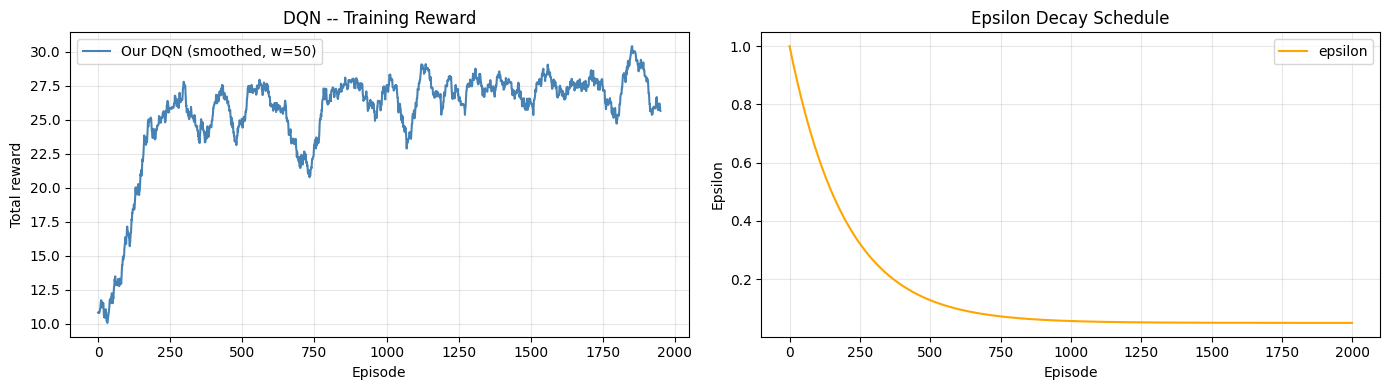

In [ ]:
dqn_arr = np.load(CKPT_DQN_R)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(smooth(dqn_arr), label='Our DQN (smoothed, w=50)', color='steelblue')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total reward')
axes[0].set_title('DQN -- Training Reward')
axes[0].legend()
axes[0].grid(alpha=0.3)

eps_curve = [
    DQN_HYPERPARAMS['epsilon_min'] + (1.0 - DQN_HYPERPARAMS['epsilon_min'])
    * np.exp(-ep / DQN_HYPERPARAMS['decrease_epsilon_factor'])
    for ep in range(len(dqn_arr))
]
axes[1].plot(eps_curve, color='orange', label='epsilon')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Epsilon')
axes[1].set_title('Epsilon Decay Schedule')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/dqn/training_curve.png', dpi=150)
plt.show()

## 4. Stable-Baselines3 DQN

We train SB3's `DQN` on the same environment with matched hyperparameters
(gamma, lr, batch size, buffer, target update) for a **controlled, fair comparison**.
The `MlpPolicy` with `net_arch=[256, 256]` matches our custom `Net` architecture.

In [ ]:
from stable_baselines3 import DQN as SB3DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor


class RewardCallback(BaseCallback):
    """Records per-episode rewards during SB3 training."""
    def __init__(self):
        super().__init__()
        self.ep_rewards = []
        self._cur = 0.0

    def _on_step(self):
        self._cur += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.ep_rewards.append(self._cur)
            self._cur = 0.0
        return True


CKPT_SB3 = 'results/sb3/sb3_dqn'
CKPT_SB3_R = 'results/sb3/train_rewards.npy'

sb3_env = gym.make('highway-v0', render_mode=None)
sb3_env.unwrapped.configure(HIGHWAY_CONFIG)
sb3_env.reset(seed=GLOBAL_SEED)
sb3_env = Monitor(sb3_env)

if os.path.exists(CKPT_SB3 + '.zip'):
    sb3_agent = SB3DQN.load(CKPT_SB3, env=sb3_env)
    sb3_rewards = np.load(CKPT_SB3_R).tolist()
    print(f'SB3 checkpoint loaded -- {len(sb3_rewards)} episodes.')
else:
    cb = RewardCallback()
    sb3_agent = SB3DQN(
        'MlpPolicy', sb3_env,
        gamma=SB3_HYPERPARAMS['gamma'],
        learning_rate=SB3_HYPERPARAMS['learning_rate'],
        batch_size=SB3_HYPERPARAMS['batch_size'],
        buffer_size=SB3_HYPERPARAMS['buffer_size'],
        learning_starts=SB3_HYPERPARAMS['learning_starts'],
        target_update_interval=SB3_HYPERPARAMS['target_update_interval'],
        train_freq=SB3_HYPERPARAMS['train_freq'],
        exploration_fraction=SB3_HYPERPARAMS['exploration_fraction'],
        exploration_initial_eps=SB3_HYPERPARAMS['exploration_initial_eps'],
        exploration_final_eps=SB3_HYPERPARAMS['exploration_final_eps'],
        policy_kwargs=SB3_HYPERPARAMS['policy_kwargs'],
        seed=GLOBAL_SEED,
        verbose=0,
    )
    sb3_agent.learn(total_timesteps=SB3_HYPERPARAMS['total_timesteps'], callback=cb)
    sb3_agent.save(CKPT_SB3)
    sb3_rewards = cb.ep_rewards
    np.save(CKPT_SB3_R, np.array(sb3_rewards))
    print(f'SB3 training done ({len(sb3_rewards)} episodes). Saved.')

In [ ]:
sb3_arr = np.load(CKPT_SB3_R)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smooth(dqn_arr), label='Our DQN', color='steelblue')
ax.plot(smooth(sb3_arr), label='SB3 DQN', color='seagreen')
ax.set_xlabel('Episode')
ax.set_ylabel('Total reward (smoothed, w=50)')
ax.set_title('Training Curves -- Our DQN vs SB3 DQN')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/training_comparison.png', dpi=150)
plt.show()

## 5. Evaluation

All agents are evaluated **greedily** (epsilon = 0) over:
- **3 seeds**: 100, 200, 300 (never used during training)
- **50 episodes per seed** = 150 total evaluation episodes per agent

A **random agent** provides the lower-bound baseline.

In [ ]:
EVAL_SEEDS = [100, 200, 300]
N_EVAL = 50

eval_env = gym.make('highway-v0', render_mode=None)
eval_env.unwrapped.configure(HIGHWAY_CONFIG)
eval_env.reset()


def full_eval(get_action_fn, env, seeds=EVAL_SEEDS, n_eps=N_EVAL):
    per_seed = {s: eval_agent(get_action_fn, env, n_episodes=n_eps, seed=s)
                for s in seeds}
    all_r = np.concatenate(list(per_seed.values()))
    return per_seed, float(all_r.mean()), float(all_r.std())


random_fn = lambda obs: np.random.randint(N_ACTIONS)
dqn_fn    = lambda obs: agent.get_action(obs, epsilon=0.0)
sb3_fn    = lambda obs: int(sb3_agent.predict(obs, deterministic=True)[0])

print('Evaluating Random...')
rand_per, rand_mean, rand_std = full_eval(random_fn, eval_env)

print('Evaluating Our DQN...')
dqn_per, dqn_mean, dqn_std = full_eval(dqn_fn, eval_env)

print('Evaluating SB3 DQN...')
sb3_per, sb3_mean, sb3_std = full_eval(sb3_fn, eval_env)

print('Done.')

In [ ]:
def fmt_row(per_seed, mean, std):
    row = {f'seed {s}': f'{v.mean():.3f} +/- {v.std():.3f}'
           for s, v in per_seed.items()}
    row['Overall (150 runs)'] = f'{mean:.3f} +/- {std:.3f}'
    return row

table = pd.DataFrame({
    'Random':  fmt_row(rand_per, rand_mean, rand_std),
    'Our DQN': fmt_row(dqn_per,  dqn_mean,  dqn_std),
    'SB3 DQN': fmt_row(sb3_per,  sb3_mean,  sb3_std),
}).T
print(table.to_string())
table.to_csv('results/evaluation_table.csv')

# Bar chart
fig, ax = plt.subplots(figsize=(7, 5))
names  = ['Random', 'Our DQN', 'SB3 DQN']
means  = [rand_mean, dqn_mean, sb3_mean]
stds   = [rand_std,  dqn_std,  sb3_std]
colors = ['#888888', 'steelblue', 'seagreen']
bars = ax.bar(names, means, yerr=stds, capsize=8, color=colors, alpha=0.85)
ax.set_ylabel('Mean reward (150 evaluation runs)')
ax.set_title('Evaluation Comparison')
ax.grid(axis='y', alpha=0.3)
for bar, m in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
        f'{m:.3f}', ha='center', va='bottom', fontsize=10
    )
plt.tight_layout()
plt.savefig('results/evaluation_bar_chart.png', dpi=150)
plt.show()

## 6. Qualitative Behavior Analysis

We run the DQN policy for 30 greedy episodes and record:
- **Action distribution**: which actions does the agent prefer?
- **Episode length**: does the agent survive the full 40 steps?
- **Collision rate**: how often does it crash?
- **Speed profile**: normalized ego-vehicle longitudinal speed (vx from Kinematics)

In [ ]:
def run_behavior(get_action_fn, env, n_episodes=30, seed=200):
    action_counts = np.zeros(N_ACTIONS, dtype=int)
    ep_lengths, ep_rewards, collisions = [], [], 0
    speeds = []

    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        total, steps, done = 0.0, 0, False
        while not done:
            action = get_action_fn(obs)
            action_counts[action] += 1
            speeds.append(obs[0, 3])  # ego vx (normalized)
            obs, r, term, trunc, _ = env.step(action)
            total += r
            steps += 1
            done = term or trunc
            if term:
                collisions += 1
        ep_lengths.append(steps)
        ep_rewards.append(total)

    return action_counts, ep_lengths, ep_rewards, collisions, speeds


ac, ep_len, ep_rew, collisions, speeds = run_behavior(dqn_fn, eval_env)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

labels = [ACTION_NAMES[i] for i in range(N_ACTIONS)]
axes[0].bar(labels, ac / ac.sum(), color='steelblue', alpha=0.8)
axes[0].set_title('Action Distribution')
axes[0].set_ylabel('Fraction of steps')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(ep_len, bins=10, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('Episode Length Distribution')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)

axes[2].plot(ep_rew, marker='o', color='steelblue', alpha=0.7, markersize=4)
axes[2].axhline(np.mean(ep_rew), color='red', linestyle='--',
                label=f'mean={np.mean(ep_rew):.3f}')
axes[2].set_title('Reward per Episode')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Total reward')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/behavior_analysis.png', dpi=150)
plt.show()

max_dur = HIGHWAY_CONFIG['duration']
print(f'Collision rate  : {collisions/30:.1%}  ({collisions}/30 episodes)')
print(f'Mean ep. length : {np.mean(ep_len):.1f} steps  (max={max_dur})')
print(f'Mean speed (vx) : {np.mean(speeds):.3f}  (normalized, 1.0 = max speed)')

## 7. Failure Mode Analysis

We search for a **collision episode** and analyse the steps leading up to it.

**Expected pattern:** The agent tends to fail when it accelerates into a slow cluster or attempts a lane change into an occupied gap. The Kinematics representation provides relative positions and velocities, but does not encode whether a lateral gap will stay clear once the lane change completes -- the agent sometimes misjudges timing.

In [ ]:
def find_failure(get_action_fn, env, max_attempts=200, seed=500):
    for i in range(max_attempts):
        obs_hist, act_hist = [], []
        obs, _ = env.reset(seed=seed + i)
        done = False
        while not done:
            action = get_action_fn(obs)
            obs_hist.append(obs.copy())
            act_hist.append(action)
            obs, _, term, trunc, _ = env.step(action)
            done = term or trunc
            if term:
                print(f'Collision found at seed={seed + i}, step={len(act_hist)}')
                return obs_hist, act_hist
    print('No collision found in search window.')
    return None, None


obs_hist, act_hist = find_failure(dqn_fn, eval_env)

if act_hist is not None:
    print(f'Last 10 actions: {[ACTION_NAMES[a] for a in act_hist[-10:]]}')

    ego_vx = [o[0, 3] for o in obs_hist]
    n1_vx  = [o[1, 3] for o in obs_hist]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(ego_vx, label='Ego vx', color='steelblue')
    axes[0].plot(n1_vx, label='Nearest vehicle vx', color='orange', linestyle='--')
    axes[0].axvline(len(ego_vx) - 1, color='red', linestyle=':', label='Collision')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Normalized speed')
    axes[0].set_title('Failure Episode -- Speed Profile')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].step(range(len(act_hist)), act_hist, color='steelblue', where='post')
    axes[1].axvline(len(act_hist) - 1, color='red', linestyle=':', label='Collision')
    axes[1].set_yticks(range(N_ACTIONS))
    axes[1].set_yticklabels([ACTION_NAMES[i] for i in range(N_ACTIONS)])
    axes[1].set_xlabel('Step')
    axes[1].set_title('Failure Episode -- Action Sequence')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/failure_mode.png', dpi=150)
    plt.show()

## 8. Design Choices

### Network architecture

We use **two hidden layers of 256 units** instead of TP4's single layer of 128.
The highway state encodes interactions between the ego vehicle and 4 surrounding vehicles (relative positions and speeds). A single layer may not capture non-linear interdependencies such as "vehicle ahead is slower **and** a lateral gap is available". Adding depth empirically improves convergence without introducing instability.

### Hyperparameter choices

| Parameter | Value | Justification |
|---|---|---|
| gamma | 0.9 | Episodes last 40 steps. gamma^40 = 0.015, focusing the agent on near-future consequences and reducing variance from long-horizon uncertainty. |
| buffer | 15 000 | ~375 full episodes. Large enough to decorrelate samples (addresses the deadly triad), but not so large that very stale early-exploration transitions dominate. |
| target sync | 200 steps | ~5 episodes. Stable enough to prevent the target from moving too fast, but fresh enough to track learning progress. Consistent with TP4. |
| epsilon decay | 200 episodes | At ep=200: eps~0.40; at ep=600: eps~0.10. Provides ~600 episodes of significant exploration before converging. |
| lr | 5e-4 | Standard Adam learning rate. Slightly lower than TP4 (1e-3) to compensate for the richer loss landscape of highway-v0. |

### Comparison methodology

Both DQN variants use the **same core hyperparameters** (gamma, lr, batch, buffer, target update).
SB3's `exploration_fraction=0.3` makes epsilon reach its minimum at 0.3 x 80 000 = 24 000 steps (~600 episodes), matching our exponential decay schedule.
Both are evaluated on the **same 3 seeds** (100, 200, 300) with **50 runs each**, ensuring a fair and reproducible comparison.